### This notebook details the processing, formatting and analysis of the data generated from the simulation runs with different group sizes.  

Thejasvi Beleyur, Max Planck Institute for Ornithology, Seewiesen
Last Updated : October 2019

In [ ]:
import random
import dill 
import datetime as dt
import glob 
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import pandas as pd
import scipy.spatial as spatial
import sys 
wd="../"
sys.path.append(wd+'//CPN//')
import numpy as np 
import statsmodels.api as sm
from tqdm import tqdm_notebook, tqdm
import brokenaxes

In [62]:
## A series of functions to parse the  simulation output
def get_run_uuid(sim_output, **kwargs):
    sim_id, sim_data = sim_output
    return(sim_id['uuid'])

def get_run_random_seed(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    random_seed = sim_ids['np.random.seed']
    return(random_seed)

def get_num_echoes_heard(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    num_echoes_heard = np.sum(sim_data[0])
    return(num_echoes_heard)

which_echo = {True: 1 , False:0}

def get_echoids(sim_data, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    echo_indices = np.argwhere(sim_data[0]==which_echo[heard]).flatten()
    return(echo_indices)    

def get_echo_levels(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output
    echo_ids = get_echoids(sim_data, **kwargs)
    
    echo_levels = sim_data[1]['target_echoes'].loc[echo_ids,'level']
    return(echo_levels)
    

def get_group_size(sim_output, **kwargs):
    ''' This function is necessary because of the
    stupid way I stored the parameter sets using classes
    '''
    sim_ids, sim_data = sim_output
    num_bats_in_group = sim_data[0].size +1 
    return(num_bats_in_group)

def split_by_groupsize(df):
    all_subdfs = []
    group_sizes = np.unique(df['groupsize'])
    for each_groupsize in group_sizes:
        subdf = df[df['groupsize']==each_groupsize]
        all_subdfs.append(subdf)
    return(group_sizes, all_subdfs)



def get_individual_positions(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    _, _b, geometry = sim_data
    positions = geometry['positions']
    return(positions)


def get_detection_distance(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    individuals_inds = echo_inds +1 # because focal individ is 0 index
    all_positions = get_individual_positions(sim_output)
    heard_individual_positions = all_positions[individuals_inds,:]
    focal_ind = all_positions[0,:]
    distances = spatial.distance
    
    positions_of_relevance = np.row_stack((focal_ind, heard_individual_positions))
    distances = spatial.distance_matrix(positions_of_relevance, 
                                        positions_of_relevance)[1:,0]
    return(distances)

def get_detection_azimuth(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    
    echoes_heard, sounds, geom = sim_data
    echoes = sounds['target_echoes']
    echo_azimuth = np.array(echoes['theta'][echo_inds])
    
    return(echo_azimuth)


def get_echo_levels(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    
    echoes_heard, sounds, geom = sim_data
    echoes = sounds['target_echoes']
    echo_level = np.array(echoes['level'][echo_inds])
    
    return(echo_level)
    


def get_nearest_neighbour_distances(sim_output, **kwargs):
    '''Extract the distance to the nearest neighbour of the focal bat
    
    Parameters
    -----------
    sim_output : output from a simulation run. 
    
    Keyword Arguments
    ------------------
    nearest_nbrs : int.
                    The number of distance measurements given. 
                    Defaults to 5. 


    Returns
    ---------
    nearest_neighbour_distances : 1 x nearest_nbrs np.array
    '''
    nearest_nbrs = kwargs.get('nearest_nbrs',5)
    positions = get_individual_positions(sim_output)
    distances = spatial.distance_matrix(positions, positions)[1:,0]
    nearest_neighbour_distances = np.sort(distances)[:nearest_nbrs]
    return(nearest_neighbour_distances)

def get_furthest_bat2bat_distance(sim_output, **kwargs):
    '''
    '''
    positions = get_individual_positions(sim_output)
    distances = spatial.distance_matrix(positions, positions)
    furthest_distance = np.max(distances)
    return(furthest_distance)
    

def extract_parameter_values(one_sim_result, **kwargs):
    '''
    Extracts the variables from the simulation result
    by extracting the values from the 
    'parameter set'
    
    Parameters
    -----------
    one_sim_results : tuple/list with 2 entries. 
                      entry 1 should have the simulation identifiers
                      entry 2 may be anything.
    Keyword Arguments
    -----------------
    variables_to_extract : list with str.
                           The names of the variables that are to be extracted.
                           Notes: 
                           If 'source_level' is one of the variables - only the 
                           emitted levels as dBSPL is output - the reference distance
                           is *ignored*.

    Returns
    --------
    param_set : list.
                A list with the numeric or Boolean values of each of the variables extracted. 
    '''
    sim_identifiers, sim_data = one_sim_result
    all_parameter_values = sim_identifiers['parameter_set']
    
    param_set_for_this_run = []
    for each in kwargs['variables_to_extract']:
        if each != 'source_level':
            param_set_for_this_run.append(all_parameter_values[each])
        elif each == 'source_level':
            param_set_for_this_run.append(all_parameter_values[each]['dBSPL'])
    
    return(param_set_for_this_run)
        
make_to_string = lambda X: str(X)

def join_all_parameters(parameter_list):
    '''
    '''
    params_as_string = map(make_to_string, parameter_list)
    param_joined = '*'.join(params_as_string)
    return(param_joined)

def make_paramset_id(sim_output, **kwargs):
    '''
    '''
    all_parameter_values = extract_parameter_values(sim_output, **kwargs)
    param_id = join_all_parameters(all_parameter_values)
    return(param_id)


def load_simresult(path_to_simresult):
    '''
    '''
    with open(path_to_simresult, 'rb') as sim:
        output = dill.load(sim)
    return(output)

def load_and_extract(simresult_path, extraction_functions, **kwargs):
    '''
    Parameters
    ----------
    simresult_path : str/path object

    extraction_functions : list/tuple with one or more function that work on 
                            the simulation output

    Keyword Arguments
    -----------------
    As defined by the extraction functions. 
    Every key must be unique and correspond to a particular extraction function!

    Returns
    ---------
    extracted_output : object type thats returned by the extraction function
    '''
    simresult = load_simresult(simresult_path)
    extracted_outputs = [ extract(simresult, **kwargs) for extract in extraction_functions]
    return(extracted_outputs)

In [63]:
# Some functions that deal with formatting the simulation data after it's been loaded from the csv file. 

def format_nearest_neighbour_distances(nearest_nbr_entry):
    '''
    Parameters
    ----------
    nearest_nbr_entry : string. 
                        pd.DataFrame column entry with 
                        the following format 
                        '[<float>, <float>, <float>]'
    
    Returns
    -------
    np.array
    
    '''
    only_float_as_string = nearest_nbr_entry[1:-1]
    all_strings_separated = only_float_as_string.split()
    floats = map(lambda X : float(X), all_strings_separated)
    
    distances = np.array(floats)
    return(distances)
    
def split_parameters_joint_to_separate_columns(row, col_names):
    for colnam, value in zip(col_names, row['parameters_joint']):
        row[colnam] = value
    return(row)


In [64]:
results_folder = wd+'//simulation_results//'
folder_id= "/non_central_0.75/"

In [65]:
all_results = glob.glob(results_folder+folder_id+'*.simresults')
some_results =random.sample(all_results, int(len(all_results)*1.0))
all_results

['/home/adityamoger/Documents/GitHub/cocktail_clone///simulation_results///non_central_0.75/group_size_a63c6bd7-8f17-4dd7-8126-8bbc0b86b280_393790120_.simresults',
 '/home/adityamoger/Documents/GitHub/cocktail_clone///simulation_results///non_central_0.75/group_size_b0f41dd5-4406-439d-8b4a-a05156a8882a_487966946_.simresults',
 '/home/adityamoger/Documents/GitHub/cocktail_clone///simulation_results///non_central_0.75/group_size_e7ed3069-fe54-49f4-bcd5-5a37c1a8a306_410481493_.simresults',
 '/home/adityamoger/Documents/GitHub/cocktail_clone///simulation_results///non_central_0.75/group_size_06c370ab-729e-45ea-a3a7-c048a19ef82e_1018462987_.simresults',
 '/home/adityamoger/Documents/GitHub/cocktail_clone///simulation_results///non_central_0.75/group_size_a04c3c96-d2bb-4d8d-a40f-088113ed2ad7_152006278_.simresults',
 '/home/adityamoger/Documents/GitHub/cocktail_clone///simulation_results///non_central_0.75/group_size_9feea8b1-4963-414c-82a6-a0c18da42cae_840833224_.simresults',
 '/home/adityam

In [66]:
extraction_fns = [get_num_echoes_heard, get_group_size, get_furthest_bat2bat_distance,
                 get_nearest_neighbour_distances, get_detection_distance, get_run_uuid,
                  get_run_random_seed,make_paramset_id, extract_parameter_values,
                 get_echo_levels, get_detection_azimuth]
keyword_arguments = {'nearest_nbrs':3}

In [67]:
keyword_arguments['variables_to_extract'] = ['heading_variation', 'echocall_duration','atmospheric_attenuation','min_spacing','source_level',
                        'interpulse_interval', 'implement_shadowing',
                                            ]

In [68]:
what_to_do = input('Do you want to "rerun" from scratch or 2, "reanalyse" from previous data')

In [69]:
what_to_do

'rerun'

In [70]:
#### Un comment into Python cells if you need to re-run the analysis by loading the raw data 
#### this can take a few minutes 
if what_to_do == 'rerun':
    %time extracted_simdata = Parallel(n_jobs=4)(delayed(load_and_extract)(each, extraction_fns, **keyword_arguments) for each in tqdm(some_results))
    print(extracted_simdata)
    echoes_heard = []
    group_size = []
    group_diameter = []
    nearest_3nbrs = []
    nbr_detection_range = []
    uuid = []
    seed = []
    param_ids = []
    parameter_values = []
    echo_levels = []
    detection_angle = []
    for each in extracted_simdata:
        for variable, list_to_append in zip(each, [echoes_heard, group_size, group_diameter,
                                                  nearest_3nbrs, nbr_detection_range,
                                                  uuid, seed, param_ids, parameter_values,
                                                  echo_levels, detection_angle]):
            list_to_append.append(variable)
    simulation_data = pd.DataFrame(data = {'nbrs_detected':echoes_heard,
                                      'group_size':group_size,
                                      'group_diameter':group_diameter,
                                      'nearest_neighbour_distance':nearest_3nbrs,
                                      'nbrs_detected_distance':nbr_detection_range,
                                      'uuid':uuid,
                                      'seed':seed,
                                      'paramset_id':param_ids,
                                      'parameters_joint':parameter_values,
                                      'echo_levels':echo_levels,
                                      'detection_azimuth':detection_angle})
    column_names = keyword_arguments['variables_to_extract']

    for each in column_names:
        simulation_data[each] = np.nan

    %time simulation_data = simulation_data.apply(split_parameters_joint_to_separate_columns, 1, col_names=column_names)    
    yyyymmdd = dt.datetime.now()
    timestamp = str([yyyymmdd.year,yyyymmdd.month,yyyymmdd.day,yyyymmdd.hour])
    ##### thanks to https://realpython.com/fast-flexible-pandas/#but-i-heard-that-pandas-is-slow
    data_store = pd.HDFStore('groupsize_data'+timestamp+'.h5')
    data_store['simulation_data'] = simulation_data
    data_store.close()

100%|██████████| 160/160 [00:00<00:00, 232.66it/s]


CPU times: user 233 ms, sys: 4.13 ms, total: 237 ms
Wall time: 836 ms
[[1, 30, 3.936218944241526, array([0.51018113, 0.51811844, 0.60763921]), array([0.51018113]), '62cd6036-d7fb-4d09-ae5d-abb606501fef', 353236965, '10*0.0025*-1*0.5*100*0.1*True', [10, 0.0025, -1, 0.5, 100, 0.1, True], array([70.75106637]), array([-31.998])], [2, 10, 2.0292192943264755, array([0.6096475 , 0.61077018, 0.73539708]), array([0.6096475 , 0.73539708]), '12a8a1b7-fd73-463f-bfb2-2f371a4bf9b2', 350200423, '10*0.0025*-1*0.5*100*0.1*True', [10, 0.0025, -1, 0.5, 100, 0.1, True], array([65.70434386, 63.60946544]), array([-87.5544, -40.5074])], [0, 75, 5.950571235299666, array([0.5511899 , 0.58016687, 0.67882245]), array([], dtype=float64), 'd2e56e46-9edb-4069-aee1-edb4ddd1d40d', 883469702, '10*0.0025*-1*0.5*100*0.1*True', [10, 0.0025, -1, 0.5, 100, 0.1, True], array([], dtype=float64), array([], dtype=float64)], [0, 200, 10.120596940499937, array([0.52767406, 0.56432134, 0.64654507]), array([], dtype=float64), '297

/tmp/ipykernel_13864/3004490390.py:44: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


In [71]:
if what_to_do == 'reanalyse':
    # show all datasets in the folder
    data_stores_in_folder = glob.glob('groupsize*.h5')
    datastores_by_index = pd.DataFrame(data={'data_stores':data_stores_in_folder})
    print(datastores_by_index)
    # user-inputs dataset choice:
    which_dataset = int(input('Give the index of the dataset you want to'))
    # load a pre-exisiting dataset
    #load the saved data 
    data_load = pd.HDFStore(data_stores_in_folder[-1])
    simulation_data = data_load['simulation_data']
    data_load.close()
else:
    raise IOError('Invalid input given!!')

        

OSError: Invalid input given!!

In [72]:
simulation_data.head()

,nbrs_detected,group_size,group_diameter,nearest_neighbour_distance,nbrs_detected_distance,uuid,seed,paramset_id,parameters_joint,echo_levels,detection_azimuth,heading_variation,echocall_duration,atmospheric_attenuation,min_spacing,source_level,interpulse_interval,implement_shadowing
0,1,30,3.936219,"[0.5101811307931244, 0.518118440086643, 0.6076...",[0.5101811307931244],62cd6036-d7fb-4d09-ae5d-abb606501fef,353236965,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[70.75106636760056],[-31.998],10,0.0025,-1,0.5,100,0.1,True
1,2,10,2.029219,"[0.6096475017753327, 0.6107701847153586, 0.735...","[0.6096475017753327, 0.7353970777564731]",12a8a1b7-fd73-463f-bfb2-2f371a4bf9b2,350200423,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[65.7043438624326, 63.609465440570595]","[-87.5544, -40.5074]",10,0.0025,-1,0.5,100,0.1,True
2,0,75,5.950571,"[0.5511898970157069, 0.580166868578234, 0.6788...",[],d2e56e46-9edb-4069-aee1-edb4ddd1d40d,883469702,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],10,0.0025,-1,0.5,100,0.1,True
3,0,200,10.120597,"[0.5276740605918893, 0.5643213424598928, 0.646...",[],29712a7a-6629-495e-bb37-472346428c7b,403414274,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],10,0.0025,-1,0.5,100,0.1,True
4,0,200,10.059398,"[0.5587847588977846, 0.6238016938473123, 0.635...",[],cb9919c4-e5dd-409b-bf7a-231814cbd7ea,370163677,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],10,0.0025,-1,0.5,100,0.1,True


### Were there any repeated seeds ? 

Every simulation run was executed in parallel with other runs. If I had relied on a common seed to set the simulations I would have gotten multiple *repeated* simulation outputs! I ended up using a unique 32 integer to seed every simulation run. The 32 bit integer was derived from a [uuid](https://en.wikipedia.org/wiki/Universally_unique_identifier) value generated at the initiation of the parallel simulation run. Even though uuid's are supposed to be *very* unique everytime they are generated - the fact that I brought them down to a 32 bit integer to actually set my simulations meant that there may have been some seeds that were repeated. 

 Repeated seeds are not a problem per se as long as they were repeated across different parameter sets. If the same seed was used to set two simulations with the same parameter set - the results would be identical and one of them must be removed from this dataset. 

In [73]:
seeds, count = np.unique(simulation_data['seed'], return_counts=True)
# if every seed was present only once, all seeds would be counted only once
print(np.unique(count))

[1]


#### There were no repeated seeds - let's move on to the next part

### What is the spatial span of the created groups ?
#### The bats were placed t o have a minimum distance between each other. What was the largest distance between any two bats - in essence, what was the *diameter*  of the group ?

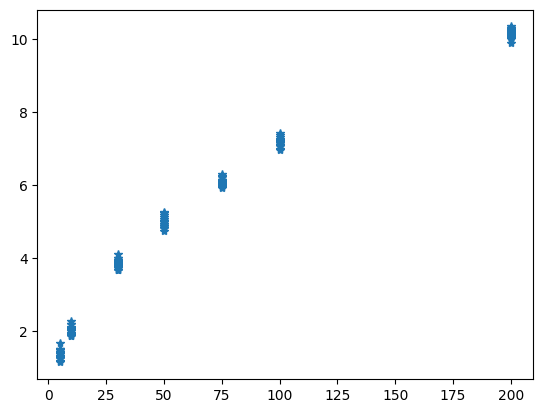

In [74]:
%matplotlib inline
plt.plot(simulation_data['group_size'],
             simulation_data['group_diameter'], 
          '*')
plt.show()

Text(0.5, 1.0, 'Group diameter, metres')

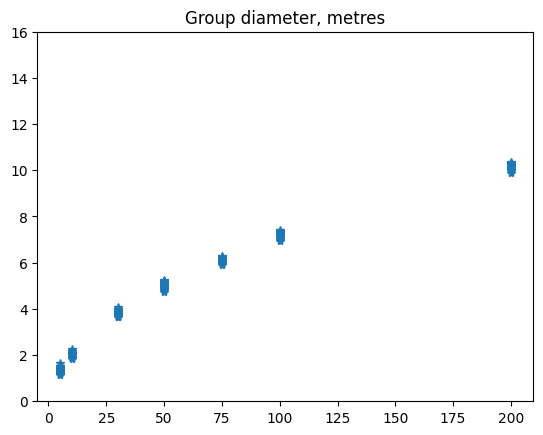

In [76]:
plt.figure()
plt.plot(simulation_data['group_size'],
             simulation_data['group_diameter'], 
          '*')
plt.yticks(np.arange(0,18,2), np.arange(0,18,2));plt.title('Group diameter, metres')
# plt.ylabel('Largest distance between two bats, metres');plt.xlabel('Minimum inter-bat spacing, metres')
# plt.grid();plt.yticks(np.arange(7,16),np.arange(7,16));plt.show()

## What is the *effective* inter-neighbour distance ? 

### In the simulations bats were randomly placed in 2D Poisson disc placement of individuals [(Bridson)](https://www.cs.ubc.ca/~rbridson/docs/bridson-siggraph07-poissondisk.pdf). The Poisson disc sampling method is a fast way to place many points that are randomly distributed while still maintaining a minimum inter-neighbour distance. This method is superior to a purely random placement of points as this results in very sparse or very dense areas. 

### Since the Poisson disc sampling method is random and only defines a *minimum* neighbour distance, I want to characterise the effective neighbour distance that was obtained. 

In [77]:
by_minspacing = simulation_data.groupby('min_spacing')

In [78]:
nearest_nbr_dist = {}
for spacing, df in by_minspacing:
    nearest_nbr_distances = df['nearest_neighbour_distance'].reset_index(drop=True)
    nearest_nbr_dist[spacing] = np.concatenate(nearest_nbr_distances)

In [79]:
nearest_nbr_dists_for_plot = [nearest_nbr_dist[0.5]]

/tmp/ipykernel_13864/193600032.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=10)


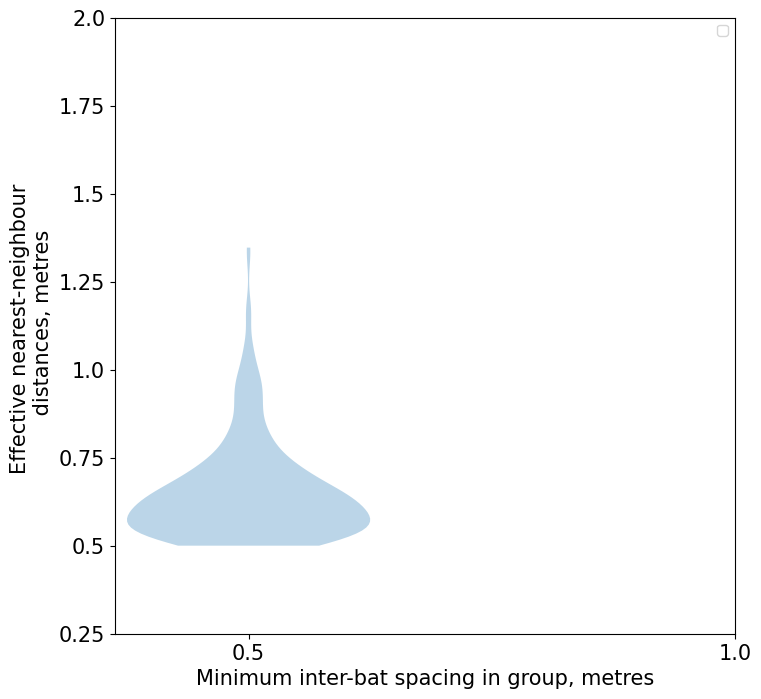

In [80]:
plt.figure(figsize=(8,8))
plt.violinplot(nearest_nbr_dists_for_plot, 
                           showextrema=False)
plt.xticks([1,2],[0.5,1.0],fontsize=15)
medians = list(map(np.median,nearest_nbr_dists_for_plot))
# plt.hlines(medians, [[0.8,1.8],[1.2,2.2]], label='median')
plt.legend(fontsize=10)
plt.xlabel('Minimum inter-bat spacing in group, metres', fontsize=15)
plt.ylabel('Effective nearest-neighbour \n distances, metres', fontsize=15)
plt.yticks(np.arange(0.25,2.25,0.25), np.arange(0.25,2.25,0.25),fontsize=15);


### The effective nearest-neighbour distances, as measured from the three nearest neighbours of the focal bat is:


In [81]:
nearest_nbr_dist


{0.5: array([0.51018113, 0.51811844, 0.60763921, 0.6096475 , 0.61077018,
        0.73539708, 0.5511899 , 0.58016687, 0.67882245, 0.52767406,
        0.56432134, 0.64654507, 0.55878476, 0.62380169, 0.6357978 ,
        0.50978201, 0.51682618, 0.54882249, 0.57031314, 0.66153551,
        0.95498215, 0.51140252, 0.65350243, 0.66692712, 0.50388323,
        0.53665498, 0.97977531, 0.52117461, 0.7713454 , 0.77513442,
        0.51063177, 0.75223016, 0.84665892, 0.50666245, 0.57977741,
        0.64386289, 0.59370155, 0.59693829, 0.71808965, 0.73434344,
        0.89574777, 1.14709164, 0.60348249, 0.63622357, 0.63964744,
        0.63953719, 0.82976231, 1.17957169, 0.52621441, 0.5359601 ,
        0.70732098, 0.5303078 , 0.56171674, 0.66882273, 0.6432677 ,
        0.68980917, 0.7200739 , 0.63962151, 0.68413353, 0.73316493,
        0.53105974, 0.58552579, 0.61237232, 0.56489126, 0.65666583,
        0.79314736, 0.50754517, 0.51487462, 0.60595184, 0.55519006,
        0.62685088, 0.62801752, 0.58398197,

In [ ]:
# for 0.5 m minimum spacing:
neighbour_spacing_pctile_50cm = np.percentile(nearest_nbr_dist[0.5], [5,50,95])
neighbour_spacing_pctile_50cm/0.5

array([1.01884316, 1.16864444, 1.52617536])

In [ ]:
# the realised inter-neighbour distances by the ideal (and unachievable) 0.5 m distance
neighbour_spacing_pctile_50cm

array([0.50942158, 0.58432222, 0.76308768])

#### How many simulation runs represent each group size?


In [ ]:
simulation_data.groupby(['group_size']).size()

group_size
5      15
10     15
30     15
50     15
75     15
100    15
200    15
dtype: int64

Every group size simulation is represented by at least 500  runs. 

### How does the number of neighbours detected per call vary across group size?


##### Bug report: 
18 October 2019 :  Yesterday I found a bug in the code that was used to generate secondary echo routes. All sounds in the simulations are assigned 'routes' which is identifies the path of a sound by series of numbers for each bat as it goes from source to receiver. eg. a call has two numbers in its route: (5,0) - which means the sound goes from bat 5 to bat 0. An echo has three numbers : (0,9,0) - the sound goes from bat 0 to bat 9 (the ensonified target) and then returns to bat 0. A secondary echo also has three numbers, but without repetitions because in this case the emitter, target and receiver are different. eg. (3,7,2) - which means bat three emitted a call that hit bat 7 and then reflected off to bat 2. 


The code used to generate the secondary echo paths relied on two loops, one over all potential emitters, and one over all potential targets. As explained above, the numbers in a secondary echo route have to be unique - and so I had checked in each iteration if the emitter was the same as the target. However, I had implemented his check using an 'is' operator. This was a bad choice because I was iterating over numbers. The *is* operator works best for strings and other object types - but gives unpredictable results for large numbers. This essentially meant that when I was checking the equivalent of the 'is the emitter the same as the target' - it worked reliably for all of my smaller groups - but luckily also failed reliably for all of the larger groups.

I checked the code and the problem occurs only at groupsizes of 400. The problem essentially arises because the emitter-is-target check fails at bat id numbers larger than 256. So - when the bat id number is 257, the check fails - and shows a false negative. Thus, we have a secondary echo with a route (5,5,0). Since the emitter and target are the same the distance between them is calculated to be zero -- resulting in infinite sound pressure level of the resulting secondary echo level !!!!! 

This bug was discovered only yesterday when HRG asked me to make the SI plot showing the different types of sounds in the IPI and illustrate how the masker profile is made etc -- and I saw a whole bunch of missing data because the pressure levels could not be added up sensibly. 

Right now I'm planning to exclude the 400 bat data from all the plots. To repeat - the rest of the code is fine and works as expected. Removing 400 bat data from the graphs does not change the primary results of the manuscript. The parameter space exploration results are safe because they were done with a group of 100 bats. 

In [82]:
data_by_groupsize = simulation_data.groupby(['group_size'])

In [83]:
nbrs_detected_data = {}
nbrs_detected_data['num_nbrs'] = []
nbrs_detected_data['median_num_nbrs'] = []
nbrs_detected_data['90%ile_num_nbrs'] = []
groupsizes= []
for groupsize, dataframe in data_by_groupsize:
    groupsizes.append(groupsize)
    nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
    nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
    nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))

/tmp/ipykernel_13864/368823477.py:6: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for groupsize, dataframe in data_by_groupsize:


In [84]:
breakup_x_axis  = np.arange(1,len(groupsizes)+1)+0.5


In [85]:
nbrs_detected_data['median_num_nbrs']

[4.0, 7.0, 3.0, 1.5, 1.0, 1.0, 0.0]

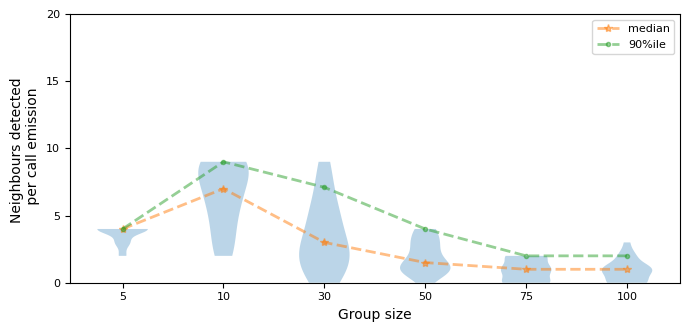

In [86]:
plt.figure(figsize=(7,3.42))
plt.violinplot(nbrs_detected_data['num_nbrs'][:-1], showextrema=False)
plt.plot(np.arange(1,len(groupsizes)),nbrs_detected_data['median_num_nbrs'][:-1],
         '--*',linewidth=2, alpha=0.5,label='median')
plt.plot(np.arange(1,len(groupsizes)), nbrs_detected_data['90%ile_num_nbrs'][:-1],
        '--.',linewidth=2, alpha=0.5, label='90%ile')
#plt.vlines(breakup_x_axis, -1,20, 'w',linewidth=30,alpha=1.0)
plt.yticks(np.arange(0,21,5),fontsize=8)
plt.xticks(range(1,len(groupsizes)),groupsizes[:-1],
           fontsize=8)
plt.legend(fontsize=8)
plt.ylabel('Neighbours detected \n per call emission', fontsize=10)
plt.xlabel('Group size', fontsize=10)
plt.ylim(0,20)
plt.tight_layout()
plt.savefig('Figure2_groupsize_1200dpi.pdf',
        bbox_inches='tight', pad_inches=0.05, format='pdf', dpi=1200)


In [87]:
# median detected neighbours per group size for 5, 10, 30, 50, 75, 100, 200, 400
nbrs_detected_data['median_num_nbrs']

[4.0, 7.0, 3.0, 1.5, 1.0, 1.0, 0.0]

In [88]:
groupsizes

[5, 10, 30, 50, 75, 100, 200]

In [89]:
nbrs_detected_data['90%ile_num_nbrs']

[4.0, 9.0, 7.100000000000001, 4.0, 2.0, 2.0, 0.10000000000000142]

In [90]:
fraction_neighbours_detected = []

In [91]:
for num_bats, detected_neighbours in zip(groupsizes, nbrs_detected_data['num_nbrs']):
    fraction_detected = detected_neighbours/(num_bats-1.0)
    fraction_neighbours_detected.append(fraction_detected)

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x790324494280>,
  <matplotlib.collections.FillBetweenPolyCollection at 0x7903242c4340>]}

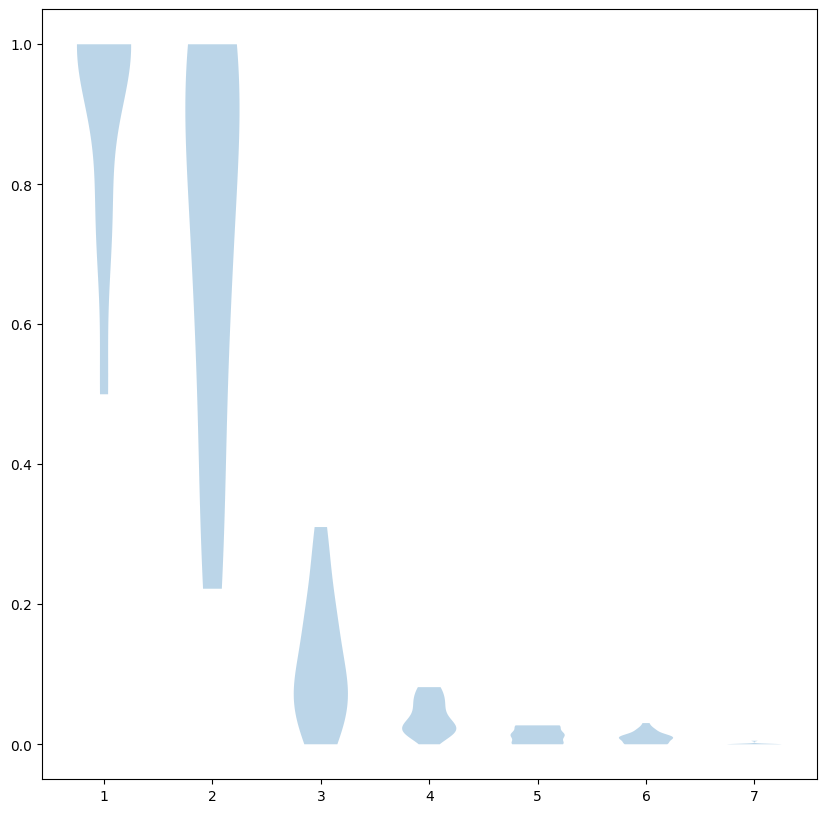

In [92]:
plt.figure(figsize=(10,10))
plt.violinplot(fraction_neighbours_detected, showextrema=False)


(0.0, 20.0)

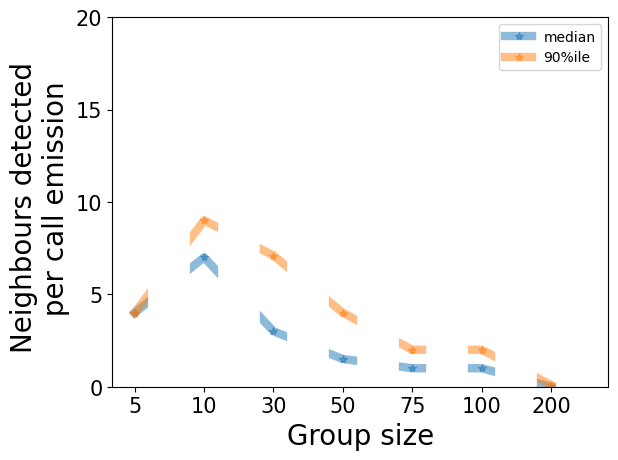

In [93]:
plt.plot(np.arange(1,len(groupsizes)+1),nbrs_detected_data['median_num_nbrs'],
         '-*',linewidth=6, alpha=0.5,label='median')
plt.plot(np.arange(1,len(groupsizes)+1), nbrs_detected_data['90%ile_num_nbrs'],
        '-*',linewidth=6, alpha=0.5, label='90%ile')
plt.vlines(breakup_x_axis, -1,20, 'w',linewidth=30,alpha=1.0)
plt.yticks(np.arange(0,21,5),fontsize=15)
plt.xticks(range(1,len(groupsizes)+1),groupsizes,
           fontsize=15)
plt.legend(); plt.ylabel('Neighbours detected \n per call emission', fontsize=20)
plt.xlabel('Group size', fontsize=20)
plt.ylim(0,20)

The number of neighbours detected shows an increase with group size initially and then drops sharply down beyond 30 bats. 


### How does the probability of detecting at least one neighbour change with group size?

In [95]:
def calculate_geqNneighbour(num_detected_neighbours, N):
    '''Calculates the proportion of an array-like
    object that is >= N.
    
    '''
    geq_N = np.float64(np.sum(num_detected_neighbours>=N))
    proportion_geq_N = geq_N/len(num_detected_neighbours)
    return(proportion_geq_N)
    

In [96]:
nbrs_detected_data['0neighbours'] = [ 1-calculate_geqNneighbour(each,1)  for each in nbrs_detected_data['num_nbrs']]
nbrs_detected_data['geq_1neighbour'] = [ calculate_geqNneighbour(each,1)  for each in nbrs_detected_data['num_nbrs']]
nbrs_detected_data['geq_2neighbour'] = [ calculate_geqNneighbour(each,2)  for each in nbrs_detected_data['num_nbrs']]
nbrs_detected_data['geq_3neighbour'] = [ calculate_geqNneighbour(each,3)  for each in nbrs_detected_data['num_nbrs']]
nbrs_detected_data['geq_4neighbour'] = [ calculate_geqNneighbour(each,4)  for each in nbrs_detected_data['num_nbrs']]

In [97]:
nbrs_detected_data['geq_1neighbour']

[1.0, 1.0, 0.9, 0.95, 0.65, 0.65, 0.1]

Text(0.5, 0, 'Group size')

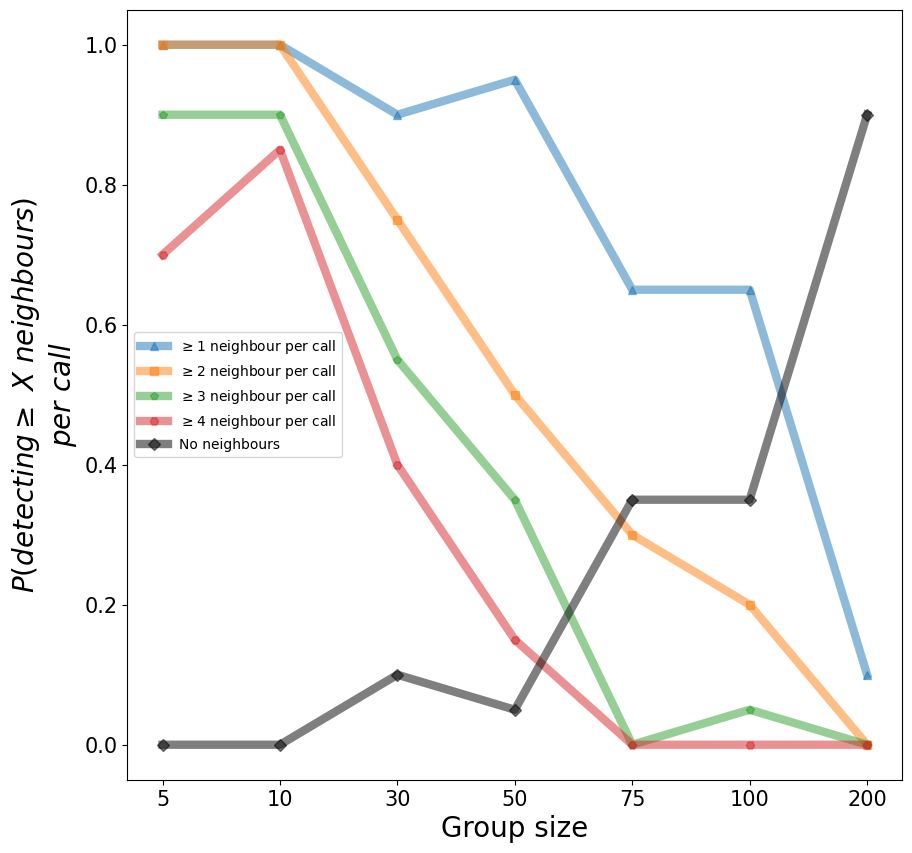

In [98]:
plt.figure(figsize=(10,10))
plt.plot(np.arange(1,len(groupsizes)+1), 
         nbrs_detected_data['geq_1neighbour'], '-^', linewidth=6, alpha=0.5, label='$\geq1$ neighbour per call')
plt.plot(np.arange(1,len(groupsizes)+1), 
         nbrs_detected_data['geq_2neighbour'], '-s', linewidth=6, alpha=0.5, label='$\geq2$ neighbour per call')
plt.plot(np.arange(1,len(groupsizes)+1), 
         nbrs_detected_data['geq_3neighbour'], '-p', linewidth=6, alpha=0.5, label='$\geq3$ neighbour per call')
plt.plot(np.arange(1,len(groupsizes)+1), 
         nbrs_detected_data['geq_4neighbour'], '-H', linewidth=6, alpha=0.5, label='$\geq4$ neighbour per call')
plt.plot(np.arange(1,len(groupsizes)+1), 
         nbrs_detected_data['0neighbours'], '-Dk', linewidth=6, alpha=0.5, label='No neighbours')

plt.yticks(fontsize=15)
plt.xticks(np.arange(1,len(groupsizes)+1),
           groupsizes,fontsize=15)
plt.legend()
plt.ylabel('$P(detecting \geq \ X \ neighbours)$'+'\n'+ '$per \ call$',
          fontsize=20)
plt.xlabel('Group size',
          fontsize=20)

In [ ]:
nbrs_detected_data['geq_1neighbour']

[1.0, 1.0, 0.9, 0.6]

In [99]:
simulation_data.head()

,nbrs_detected,group_size,group_diameter,nearest_neighbour_distance,nbrs_detected_distance,uuid,seed,paramset_id,parameters_joint,echo_levels,detection_azimuth,heading_variation,echocall_duration,atmospheric_attenuation,min_spacing,source_level,interpulse_interval,implement_shadowing
0,1,30,3.936219,"[0.5101811307931244, 0.518118440086643, 0.6076...",[0.5101811307931244],62cd6036-d7fb-4d09-ae5d-abb606501fef,353236965,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[70.75106636760056],[-31.998],10,0.0025,-1,0.5,100,0.1,True
1,2,10,2.029219,"[0.6096475017753327, 0.6107701847153586, 0.735...","[0.6096475017753327, 0.7353970777564731]",12a8a1b7-fd73-463f-bfb2-2f371a4bf9b2,350200423,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[65.7043438624326, 63.609465440570595]","[-87.5544, -40.5074]",10,0.0025,-1,0.5,100,0.1,True
2,0,75,5.950571,"[0.5511898970157069, 0.580166868578234, 0.6788...",[],d2e56e46-9edb-4069-aee1-edb4ddd1d40d,883469702,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],10,0.0025,-1,0.5,100,0.1,True
3,0,200,10.120597,"[0.5276740605918893, 0.5643213424598928, 0.646...",[],29712a7a-6629-495e-bb37-472346428c7b,403414274,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],10,0.0025,-1,0.5,100,0.1,True
4,0,200,10.059398,"[0.5587847588977846, 0.6238016938473123, 0.635...",[],cb9919c4-e5dd-409b-bf7a-231814cbd7ea,370163677,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],10,0.0025,-1,0.5,100,0.1,True


In [100]:
nbrs_detected_data['detected_distances'] = [ np.concatenate(np.array(dataframe['nbrs_detected_distance'])) for groupsize, dataframe in data_by_groupsize]
nbrs_detected_data['median_detected_distances'] = map(np.median, nbrs_detected_data['detected_distances'])
nbrs_detected_data['90%ile_detected_distances'] = map(lambda X : np.percentile(X,90),
                                                      nbrs_detected_data['detected_distances'][:-1])

/tmp/ipykernel_13864/568226531.py:1: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  nbrs_detected_data['detected_distances'] = [ np.concatenate(np.array(dataframe['nbrs_detected_distance'])) for groupsize, dataframe in data_by_groupsize]


RuntimeError: matplotlib does not support generators as input

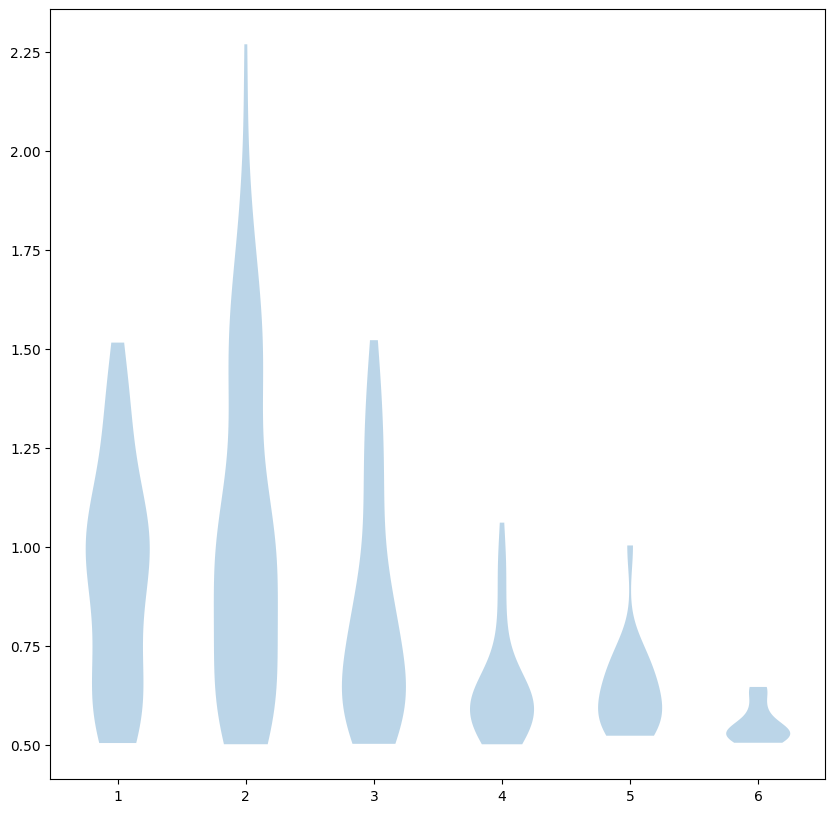

In [101]:
plt.figure(figsize=(10,10))
plt.violinplot(nbrs_detected_data['detected_distances'][:-1], 
                                                   showextrema=False,
                                                )
plt.plot(np.arange(1,9), nbrs_detected_data['median_detected_distances'], linewidth=6,
        alpha=0.5, label='median detected neighbour distance')
plt.plot(np.arange(1,8), nbrs_detected_data['90%ile_detected_distances'], linewidth=6,
        alpha=0.5, label='90%ile detected neighbour distance')
plt.xticks(np.arange(1,9), groupsizes)
plt.hlines(0.5,1,8, 'r'); 
plt.text(1.0,0.45,'Closest neighbour', fontsize=15)
plt.ylabel('Detected neighbour radial distance \n metres', fontsize=20);plt.yticks(fontsize=15)
plt.xlabel('Group size', fontsize=20);plt.xticks(fontsize=15)
plt.legend()


### Which neighbours are detected in the azimuthal plane ? 

In [103]:
nbrs_detected_data['neighbours_azimuth'] = [ np.concatenate(np.array(dataframe['detection_azimuth'])) for groupsize, dataframe in data_by_groupsize]
nbrs_detected_data['median_neighbours_azimuth'] = [ np.median(each)  for each in nbrs_detected_data['neighbours_azimuth'] ]
nbrs_detected_data['95%ile_neighbours_azimuth'] = [ np.percentile(each, 92.5)  for each in nbrs_detected_data['neighbours_azimuth'][:-1] ]
nbrs_detected_data['5%ile_neighbours_azimuth'] = [ np.percentile(each, 2.5)  for each in nbrs_detected_data['neighbours_azimuth'][:-1] ]

/tmp/ipykernel_13864/604557109.py:1: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  nbrs_detected_data['neighbours_azimuth'] = [ np.concatenate(np.array(dataframe['detection_azimuth'])) for groupsize, dataframe in data_by_groupsize]


ValueError: x and y must have same first dimension, but have shapes (8,) and (7,)

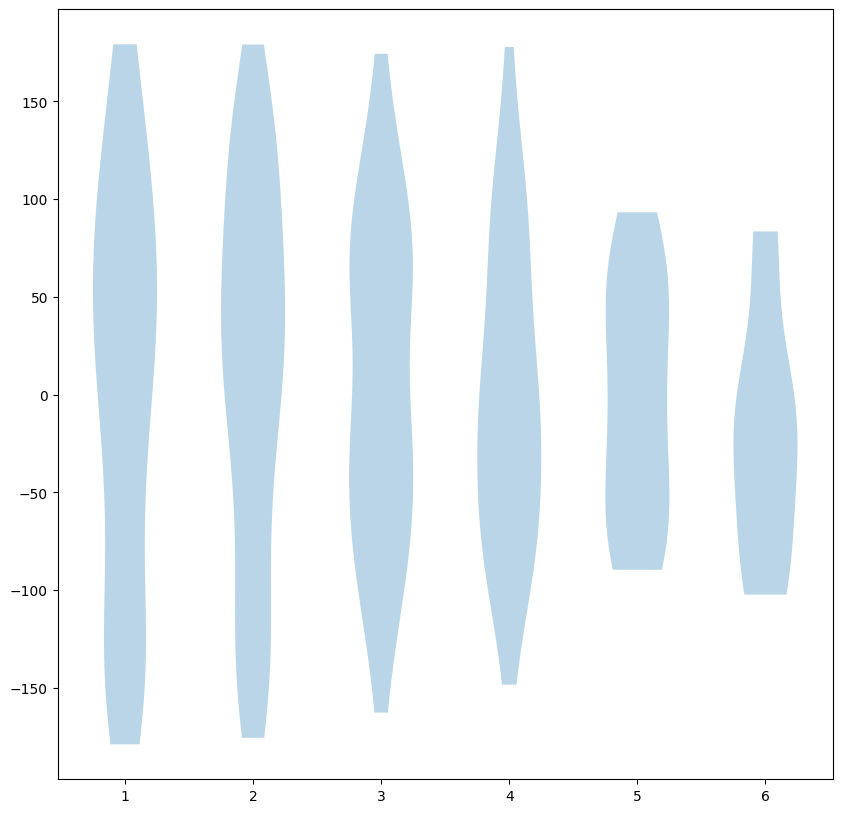

In [104]:
plt.figure(figsize=(10,10))
plt.violinplot(nbrs_detected_data['neighbours_azimuth'][:-1], showextrema=False)
plt.plot(np.arange(1,9), nbrs_detected_data['median_neighbours_azimuth'], '-*', linewidth=6,
                     alpha=0.5, label='median neighbour detection angle')
plt.vlines(range(1,len(nbrs_detected_data['5%ile_neighbours_azimuth'])+1),nbrs_detected_data['5%ile_neighbours_azimuth'],
           nbrs_detected_data['95%ile_neighbours_azimuth'], label='95% data interval')
#plt.plot(np.arange(1,8), nbrs_detected_data['95%ile_neighbours_azimuth'], 'g')
#plt.plot(np.arange(1,8), nbrs_detected_data['5%ile_neighbours_azimuth'], 'g', label='95%  neighbour detection range')

plt.yticks(np.arange(-180,210,30), np.arange(-180,210,30), fontsize=15)
plt.xticks(np.arange(1,9), groupsizes, fontsize=15)
plt.legend()
plt.ylabel('Neighbour detection angle, \n  Azimuth, $^{\circ}$', fontsize=20)
plt.xlabel('Group size', fontsize=20)

In [ ]:
neighbour_detection_angle = np.abs(nbrs_detected_data['5%ile_neighbours_azimuth']) +  nbrs_detected_data['95%ile_neighbours_azimuth']
neighbour_detection_angle = np.concatenate((neighbour_detection_angle, np.array([np.nan])))

In [ ]:
neighbour_detection_angle

array([261.05765 , 243.162115, 202.75707 ,        nan])

In [ ]:
groupsizes

[20, 30, 40, 50]

In [ ]:
pd.DataFrame(data={'neighbour_detection_angle':neighbour_detection_angle, 'groupsize':groupsizes})

,neighbour_detection_angle,groupsize
0,261.057650,20
1,243.162115,30
2,202.757070,40
3,NaN,50


### How does the received level of the echoes reflecting off neighbours change with group size?

In [105]:
nbrs_detected_data['echolevels'] = [ np.concatenate(np.array(dataframe['echo_levels'])) for groupsize, dataframe in data_by_groupsize]
nbrs_detected_data['median_echolevels'] = [ np.median(each) for each in nbrs_detected_data['echolevels']]
nbrs_detected_data['5%ile_echolevels'] = [ np.percentile(each, 2.5) for each in nbrs_detected_data['echolevels'][:-1]]
nbrs_detected_data['95%ile_echolevels'] = [ np.percentile(each, 97.5) for each in nbrs_detected_data['echolevels'][:-1]]

/tmp/ipykernel_13864/460192006.py:1: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  nbrs_detected_data['echolevels'] = [ np.concatenate(np.array(dataframe['echo_levels'])) for groupsize, dataframe in data_by_groupsize]


ValueError: x and y must have same first dimension, but have shapes (8,) and (7,)

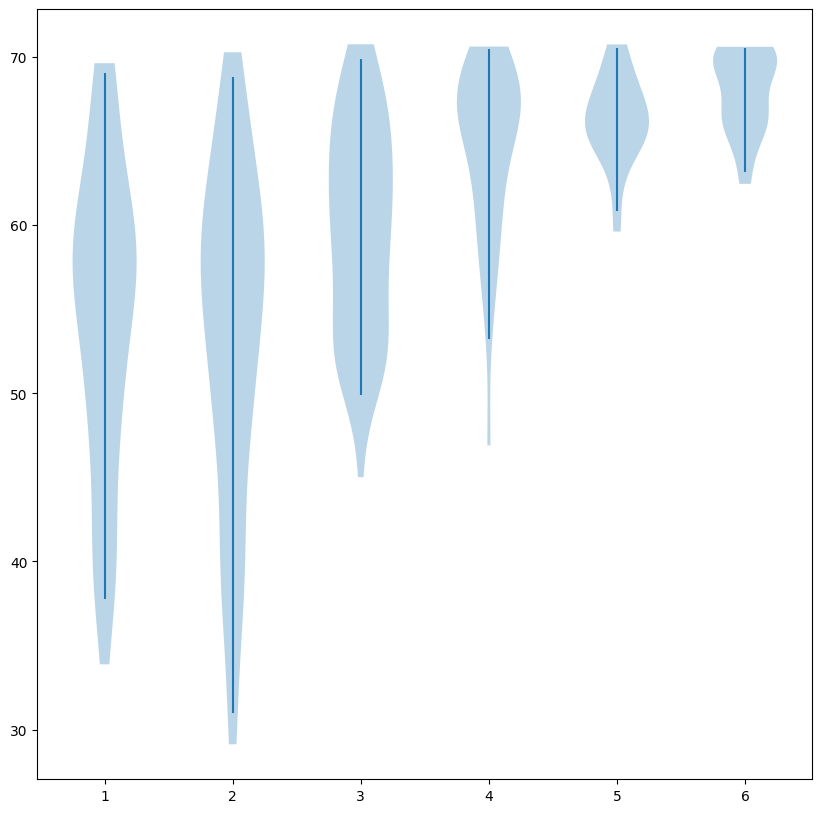

In [106]:
plt.figure(figsize=(10,10))
plt.violinplot(nbrs_detected_data['echolevels'][:-1], 
                                   showextrema=False);
plt.vlines(range(1,len(nbrs_detected_data['95%ile_echolevels'])+1),nbrs_detected_data['5%ile_echolevels'],
                                                                   nbrs_detected_data['95%ile_echolevels'],
                          label='95% data interval')

plt.plot(range(1,9), nbrs_detected_data['median_echolevels'], linewidth=6, alpha=0.5,
         label='median detected echo level')
plt.ylabel('Received level of detected echoes, \n dB SPL re 20$\mu Pa$',
                                    fontsize=20)
plt.xticks(np.arange(1,9), groupsizes, fontsize=15)
plt.hlines([20],1,8)
plt.yticks(np.arange(20,86,6),np.arange(20,86,6), fontsize=15)
plt.text(1,21,'Hearing threshold', fontsize=15)
plt.xlabel('Group size', fontsize=20)
plt.legend()

In [ ]:
groupsizes

[20, 30, 40, 50]

In [ ]:
nbrs_detected_data['geq_1neighbour']

[1.0, 1.0, 0.9, 0.6]

KeyError: 'detected_distances'

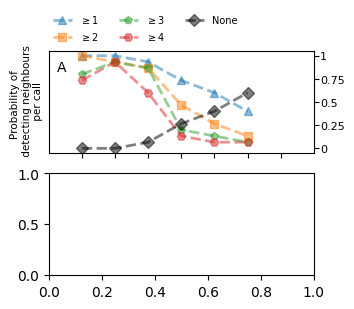

In [ ]:
relative_x, relative_y = 0.03, 0.8
plt.figure(figsize=(3.42,4.5))
A = plt.subplot(311)# prob detecting neighbours
plt.plot(np.arange(1,len(groupsizes)), 
         nbrs_detected_data['geq_1neighbour'][:-1], '--^', linewidth=2, 
         alpha=0.5, label='$\geq1$')
plt.plot(np.arange(1,len(groupsizes)), 
         nbrs_detected_data['geq_2neighbour'][:-1], '--s', linewidth=2, alpha=0.5,
         label='$\geq2$')
plt.plot(np.arange(1,len(groupsizes)), 
         nbrs_detected_data['geq_3neighbour'][:-1], '--p', linewidth=2, alpha=0.5, 
         label='$\geq3$')
plt.plot(np.arange(1,len(groupsizes)), 
         nbrs_detected_data['geq_4neighbour'][:-1], '--H', linewidth=2, alpha=0.5, 
         label='$\geq4$')
plt.plot(np.arange(1,len(groupsizes)), 
         nbrs_detected_data['0neighbours'][:-1], '--Dk', linewidth=2, alpha=0.5, label='None')
A.tick_params(axis='y', pad=1)

plt.yticks([0,0.25, 0.5,0.75,1],[0,0.25, 0.5,0.75,1],fontsize=8)
plt.xticks(np.arange(1,8),[])
plt.legend(fontsize=7, loc=(0.00,1.05),ncol=3, frameon=False)
plt.ylabel('Probability of \n detecting neighbours\n per call',
          fontsize=7.5)
A.text(relative_x, relative_y, 'A', fontsize=10, transform=A.transAxes)
A.yaxis.tick_right()
plt.xlim(0,8)


B = plt.subplot(312) # radial distance of detected neighbours
plt.violinplot(nbrs_detected_data['detected_distances'][:-1], 
                                                   showextrema=False,
                                                )
plt.plot(np.arange(1,8), nbrs_detected_data['median_detected_distances'][:-1],'--*', linewidth=2,
        alpha=0.5,label='median')
plt.plot(np.arange(1,8), nbrs_detected_data['90%ile_detected_distances'],'--.', linewidth=2,
        alpha=0.5, label='90%ile')
plt.hlines(0.5,1,7, 'r', label='minimum inter-bat \n distance', linewidth=1,
          alpha=0.7); 
#plt.text(2.0,0.5,'Closest \n neighbour', fontsize=7)
plt.ylabel('Radial distance of\n detected neighbours \n (m)', fontsize=7.5);
plt.yticks([0.5,1,1.5,2.0],fontsize=8)
plt.xticks(np.arange(1,8),[])
plt.legend(fontsize=7, frameon=False)
B.text(relative_x, relative_y, 'B', fontsize=10, transform=B.transAxes)
B.yaxis.tick_right()
plt.xlim(0,8)
plt.ylim(0.25,2.5)

C=plt.subplot(313)# angle of detected neighbours
plt.violinplot(nbrs_detected_data['neighbours_azimuth'][:-1], showextrema=False)
#plt.plot(np.arange(1,9), nbrs_detected_data['median_neighbours_azimuth'], '-*', linewidth=2,
#                     alpha=0.5, label='median neighbour detection angle')
plt.vlines(range(1,len(nbrs_detected_data['5%ile_neighbours_azimuth'])+1),nbrs_detected_data['5%ile_neighbours_azimuth'],
           nbrs_detected_data['95%ile_neighbours_azimuth'], label='95% data interval')
#plt.plot(np.arange(1,8), nbrs_detected_data['95%ile_neighbours_azimuth'], 'g')
#plt.plot(np.arange(1,8), nbrs_detected_data['5%ile_neighbours_azimuth'], 'g', label='95%  neighbour detection range')

plt.yticks(np.arange(-180,240,60), np.arange(-180,240,60), fontsize=8)
plt.xticks(np.arange(1,8), groupsizes[:-1], fontsize=9)
plt.legend(fontsize=7, frameon=False)
plt.ylabel('Neighbour azimuthal \n detection angle ($^{\circ} $)', fontsize=7.5)
plt.xlabel('Group size', fontsize=10)
C.text(relative_x, relative_y, 'C', fontsize=10, transform=C.transAxes)
C.yaxis.tick_right()
plt.xlim(0,8)

plt.savefig('Figure3_1200dpi_tight.pdf',
            bbox_inches='tight', pad_inches=0, format='pdf', dpi=1200)

In [ ]:
groupsizes

[5, 10, 30, 50, 75, 100, 200, 400]

In [ ]:
nbrs_detected_data['median_detected_distances']

[0.6280403720090145,
 0.7990232430980477,
 0.8450001703151906,
 0.6359127730784396,
 0.567084214815218,
 0.5453777813613461,
 0.5100279650531143,
 nan]